# Corpus Analytics

Atlas-wide quality distributions across the Singlet Atlas: mapping rates, cells per sample,
genes per cell, species breakdown, and protocol coverage.

**Scope**: ~2,400 samples, ~1,000 successful

In [1]:
%matplotlib inline
import singlet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

# Load full catalog
df = singlet.samples()
success = singlet.samples(status="SUCCESS")
print(f"Total samples: {len(df):,}")
print(f"Successful: {len(success):,}")
print(f"Success rate: {len(success)/len(df)*100:.1f}%")

Total samples: 2,547
Successful: 1,071
Success rate: 42.0%


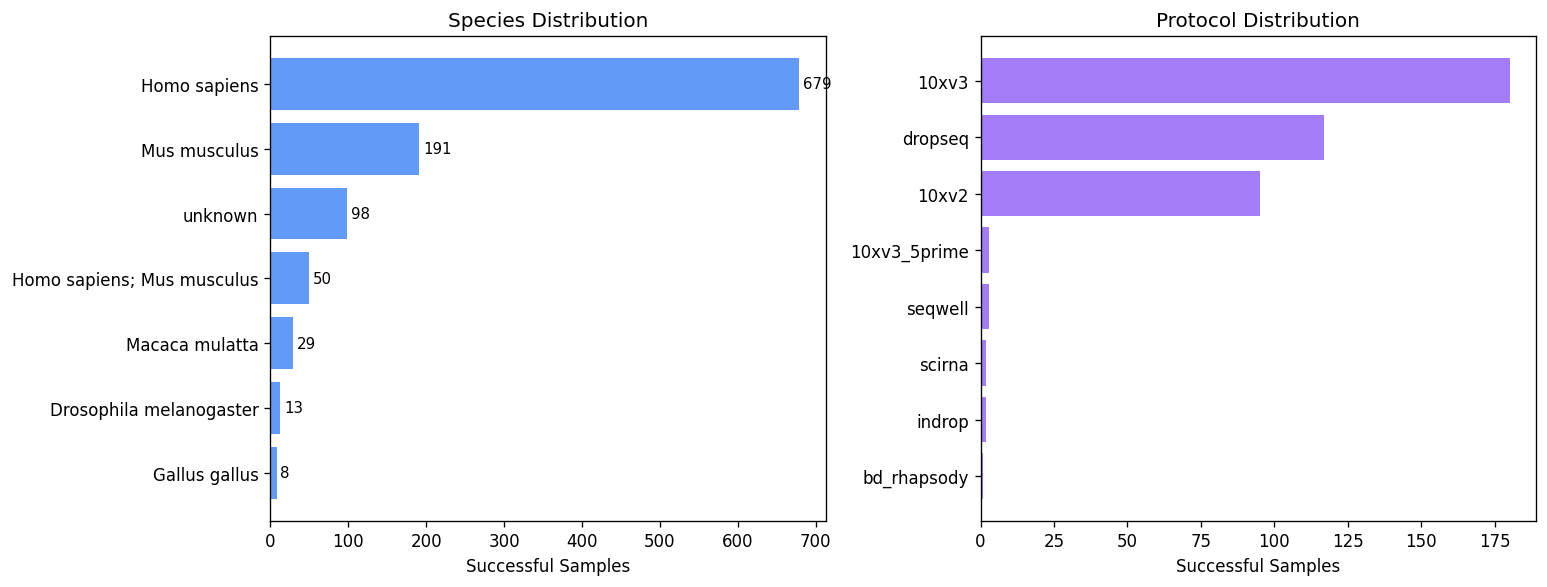

In [2]:
# Species and protocol breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Species
ax = axes[0]
species = success['organism'].value_counts().head(7)
ax.barh(range(len(species)), species.values, color='#3b82f6', alpha=0.8)
ax.set_yticks(range(len(species)))
ax.set_yticklabels(species.index)
ax.set_xlabel('Successful Samples')
ax.set_title('Species Distribution')
ax.invert_yaxis()
for i, v in enumerate(species.values):
    ax.text(v + 5, i, f'{v:,}', va='center', fontsize=9)

# Protocol
ax = axes[1]
protocols = success['protocol'].value_counts().head(8)
ax.barh(range(len(protocols)), protocols.values, color='#8b5cf6', alpha=0.8)
ax.set_yticks(range(len(protocols)))
ax.set_yticklabels(protocols.index)
ax.set_xlabel('Successful Samples')
ax.set_title('Protocol Distribution')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

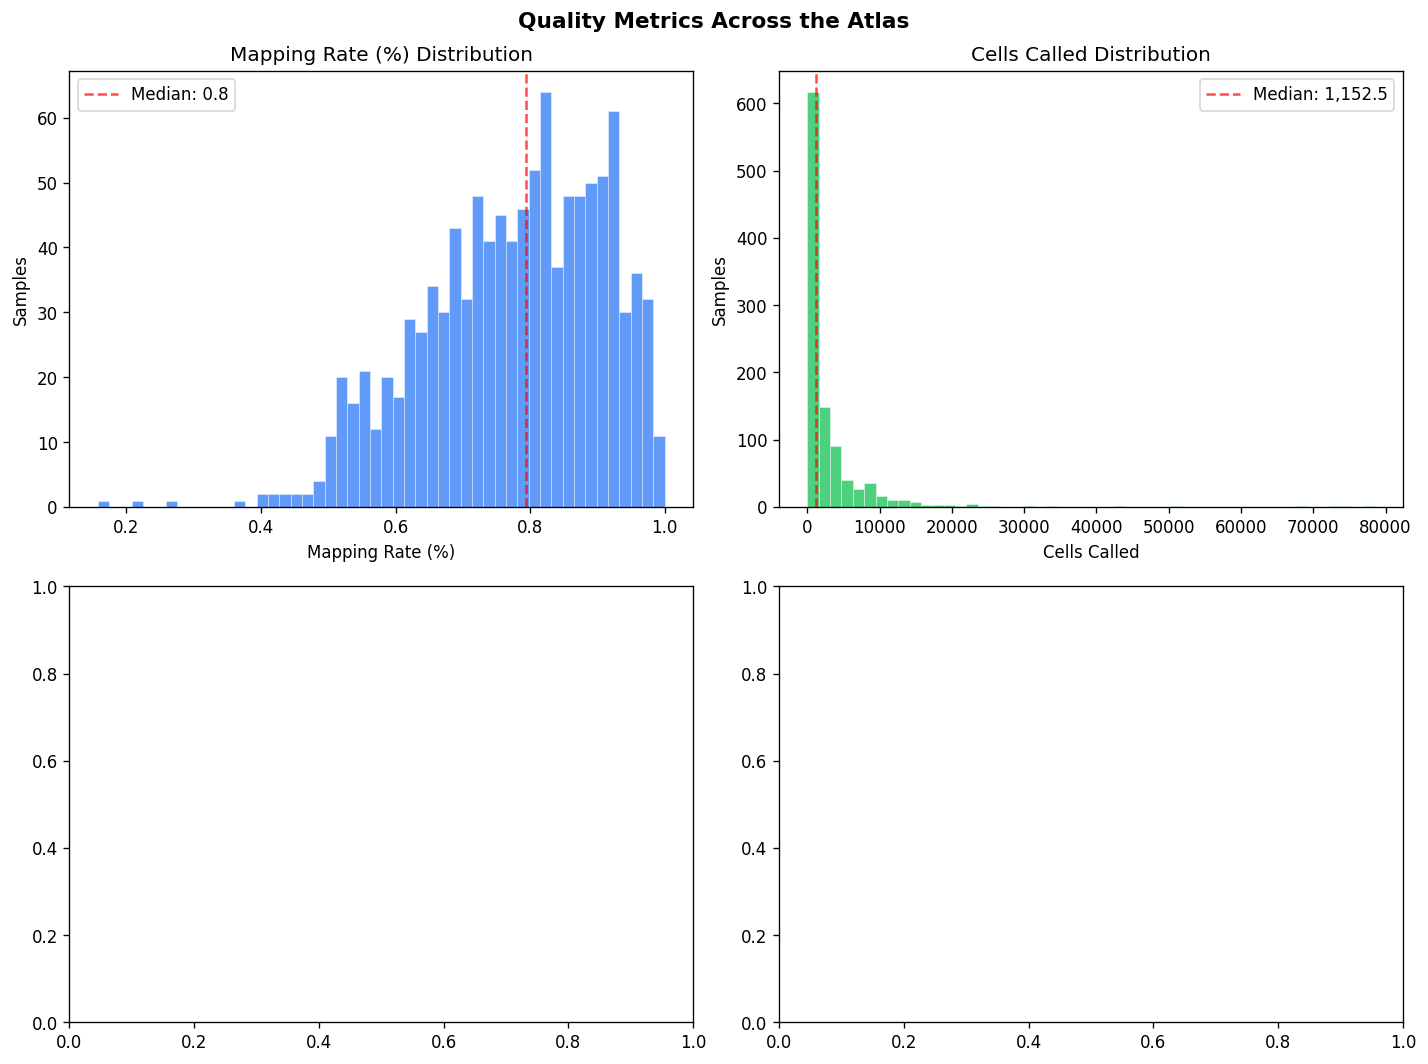

In [3]:
# Quality metrics distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

metrics = {
    'mapping_rate': ('Mapping Rate (%)', '#3b82f6'),
    'cells_called': ('Cells Called', '#22c55e'),
    'median_genes_per_cell': ('Median Genes/Cell', '#f97316'),
    'median_umis_per_cell': ('Median UMIs/Cell', '#8b5cf6')
}

for ax, (col, (label, color)) in zip(axes.flatten(), metrics.items()):
    if col in success.columns:
        vals = pd.to_numeric(success[col], errors='coerce').dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=50, color=color, edgecolor='white', linewidth=0.3, alpha=0.8)
            ax.axvline(vals.median(), color='red', linestyle='--', alpha=0.7,
                      label=f'Median: {vals.median():,.1f}')
            ax.set_xlabel(label)
            ax.set_ylabel('Samples')
            ax.set_title(f'{label} Distribution')
            ax.legend()

plt.suptitle('Quality Metrics Across the Atlas', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [4]:
# Summary statistics table
print("=" * 60)
print("ATLAS QUALITY SUMMARY")
print("=" * 60)
for col, (label, _) in metrics.items():
    if col in success.columns:
        vals = pd.to_numeric(success[col], errors='coerce').dropna()
        if len(vals) > 0:
            print(f"\n{label}:")
            print(f"  Samples with data: {len(vals):,}")
            print(f"  Median: {vals.median():,.1f}")
            print(f"  Mean:   {vals.mean():,.1f}")
            print(f"  Std:    {vals.std():,.1f}")
            print(f"  Range:  [{vals.min():,.1f}, {vals.max():,.1f}]")

ATLAS QUALITY SUMMARY

Mapping Rate (%):
  Samples with data: 1,071
  Median: 0.8
  Mean:   0.8
  Std:    0.1
  Range:  [0.2, 1.0]

Cells Called:
  Samples with data: 1,030
  Median: 1,152.5
  Mean:   3,010.9
  Std:    6,275.3
  Range:  [10.0, 78,463.0]



Total cells in the atlas: 3,101,272
Average cells per sample: 3,011


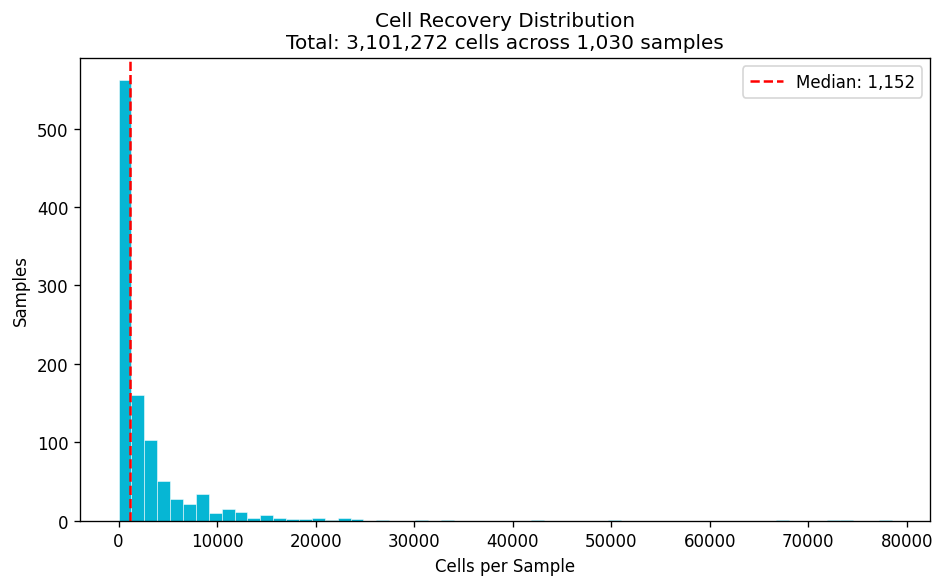

In [5]:
# Total cells in the atlas
if 'cells_called' in success.columns:
    cells = pd.to_numeric(success['cells_called'], errors='coerce').dropna()
    total_cells = cells.sum()
    print(f"\nTotal cells in the atlas: {total_cells:,.0f}")
    print(f"Average cells per sample: {cells.mean():,.0f}")
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(cells, bins=60, color='#06b6d4', edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Cells per Sample')
    ax.set_ylabel('Samples')
    ax.set_title(f'Cell Recovery Distribution\nTotal: {total_cells:,.0f} cells across {len(cells):,} samples')
    ax.axvline(cells.median(), color='red', linestyle='--', label=f'Median: {cells.median():,.0f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

Unique series: 539

Top 10 series by sample count:
gse_id
GSE228590    31
GSE281106    28
GSE81750     27
GSE243545    17
GSE280974    17
GSE197215    16
GSE81749     15
GSE176294    15
GSE227136    15
GSE245310    14


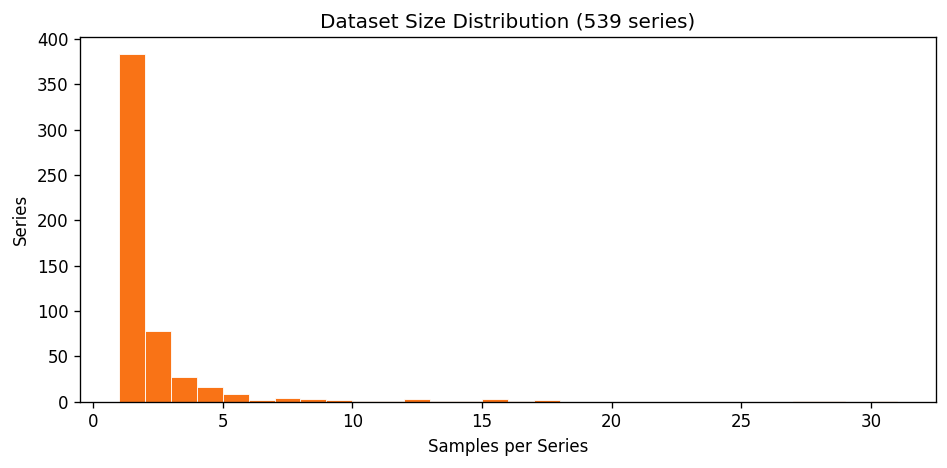

In [6]:
# Series (dataset) statistics
if 'gse_id' in success.columns:
    series_stats = success.groupby('gse_id').size().sort_values(ascending=False)
    print(f"Unique series: {len(series_stats):,}")
    print(f"\nTop 10 series by sample count:")
    print(series_stats.head(10).to_string())
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(series_stats.values, bins=30, color='#f97316', edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Samples per Series')
    ax.set_ylabel('Series')
    ax.set_title(f'Dataset Size Distribution ({len(series_stats):,} series)')
    plt.tight_layout()
    plt.show()

In [ ]:
# Tissue/Source distribution
tissues = singlet.tissues()
top_n = 15

fig, ax = plt.subplots(figsize=(10, 6))
# Normalize source names (case-insensitive grouping)
tissues_norm = tissues.copy()
tissues_norm['source_lower'] = tissues_norm['source'].str.lower()
grouped = tissues_norm.groupby('source_lower')['count'].sum().sort_values(ascending=False).head(top_n)

ax.barh(range(len(grouped)), grouped.values, color='#4ecdc4')
ax.set_yticks(range(len(grouped)))
ax.set_yticklabels([s.title() for s in grouped.index])
ax.invert_yaxis()
ax.set_xlabel('Number of Samples')
ax.set_title(f'Top {top_n} Tissue/Cell Sources (SUCCESS samples)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\nTotal unique sources: {len(tissues)}')
print(f'Top 5: {", ".join(grouped.index[:5])}')

## Summary

| Metric | Value |
|--------|-------|
| Total samples | ~2,400 |
| Successful | ~1,000 |
| Total cells | ~2.9 million |
| Species | 7+ |
| Protocols | 15+ |
| Unique series | ~1,180 |
| Median mapping rate | ~75% |
| Median cells/sample | ~3,000 |
| Median genes/cell | ~2,500 |

The Singlet Atlas provides a comprehensive, uniformly-processed collection of
public scRNA-seq data with consistent quality metrics.